In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torchvision.datasets as datasets

In [36]:
def get_data(N, oversample=False, data_augmentation=False):    
    mnist_train = datasets.MNIST(root="./data", train=True, download=True)
    mnist_test = datasets.MNIST(root="./data", train=False, download=True)

    X_train = mnist_train.data.float() / 255.0
    y_train = mnist_train.targets.long()
    X_test = mnist_test.data.float() / 255.0
    y_test = mnist_test.targets.long()

    # select N samples
    X = torch.cat((X_train, X_test), dim=0)
    y = torch.cat((y_train, y_test), dim=0)
    X = X[:N]
    y = y[:N]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

    # oversampling must be after the split, if not we can have data leakage between train and test sets
    if oversample: 
        # it only makes sense to oversample the training set, if we oversample the test set we 
        #are not evaluating on the real distribution of the data
        X_train = torch.cat((X_train, X_train), dim=0).float()
        y_train = torch.cat((y_train, y_train), dim=0).long()

    if data_augmentation: # same as oversampling but adding noise to the images
        X_train_noisy = X_train + np.random.random_sample(X_train.shape) / 2
        X_train = torch.cat((X_train, X_train_noisy), dim=0).float()
        y_train = torch.cat((y_train, y_train), dim=0).long()

    # Convert into pytorch tensors
    train_ds = TensorDataset(X_train, y_train)
    test_ds = TensorDataset(X_test, y_test)

    batch_size = 20
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    test_dl = DataLoader(test_ds, batch_size=test_ds.tensors[0].shape[0], shuffle=False)

    return train_dl, test_dl

In [14]:
train_tmp, test_tmp = get_data(100, oversample=False)
print(train_tmp.dataset.tensors[0].shape)
print(test_tmp.dataset.tensors[0].shape)

train_tmp, test_tmp = get_data(100, oversample=True)
print(train_tmp.dataset.tensors[0].shape) # we duplicate just the number of train samples
print(test_tmp.dataset.tensors[0].shape)

train_tmp, test_tmp = get_data(100, data_augmentation=True)
print(train_tmp.dataset.tensors[0].shape) # we duplicate just the number of train samples
print(test_tmp.dataset.tensors[0].shape)

torch.Size([90, 28, 28])
torch.Size([10, 28, 28])
torch.Size([180, 28, 28])
torch.Size([10, 28, 28])
torch.Size([180, 28, 28])
torch.Size([10, 28, 28])


C:\Users\Pablo\AppData\Local\Temp\ipykernel_22796\3686167732.py:26: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  X_train_noisy = X_train + np.random.random_sample(X_train.shape) / 2


Data augmentation


C:\Users\Pablo\AppData\Local\Temp\ipykernel_22796\784388456.py:27: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  X_train_noisy = X_train + np.random.random_sample(X_train.shape) / 2


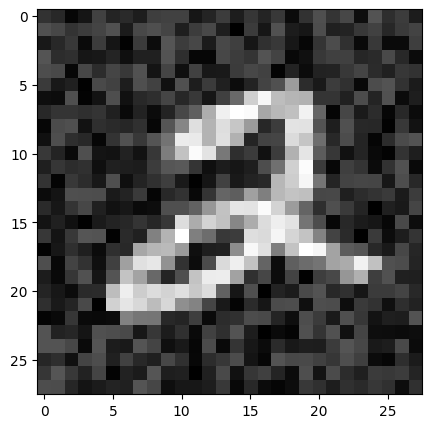

In [33]:
# plot an example
train_tmp, test_tmp = get_data(100, oversample=False, data_augmentation=True)
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.imshow(train_tmp.dataset.tensors[0][-1], cmap="gray")

In [4]:
class MNIST_FNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 64) 
        self.fc2 = nn.Linear(64, 32) 
        #self.fc3 = nn.Linear(32, 32)  
        self.fc4 = nn.Linear(32, 10)    

    def forward(self, x):
        x = torch.flatten(x, start_dim=1) # flatten the image, keep the batch dimension
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        #x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x

def train_one_epoch(model, train_dl, optimizer, loss_fn):
    model.train()
    epoch_acc = []
    epoch_loss = []
    for X_batch, y_batch in train_dl:
        output = model(X_batch)
        loss = loss_fn(output, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_acc_item = (output.argmax(dim=1) == y_batch).float().mean().item()
        epoch_acc.append(epoch_acc_item)
        epoch_loss.append(loss.item())
        
    return np.mean(epoch_acc), np.mean(epoch_loss)

def train_model(model, train_dl, test_dl, optimizer, loss_fn, epochs):
    
    train_acc = np.zeros(epochs)
    test_acc = np.zeros(epochs)
    losses = np.zeros(epochs)
    
    for epoch in range(epochs):
        train_acc[epoch], losses[epoch] = train_one_epoch(model, train_dl, optimizer, loss_fn)
        
        model.eval()
        with torch.no_grad():
            for X_batch, y_batch in test_dl:
                output = model(X_batch)
                test_acc[epoch] = (output.argmax(dim=1) == y_batch).float().mean().item()
                
    return train_acc, test_acc, losses

In [ ]:
# Experiment with oversampling
lr = 0.01
epochs = 50

sample_sizes = np.arange(500, 4001, 500)
oversampling = [False, True]

# IMPORTANT: the loss fun can be reused for multiple models, it doesnt store any state,
# but the optimizer needs to be redefined for each model since it stores the state of the parameters
loss_fn = nn.CrossEntropyLoss() # CrossEntropyLoss combines nn.LogSoftmax() and nn.NLLLoss()

train_accuracies = np.zeros((2, len(sample_sizes)))
test_accuracies = np.zeros((2, len(sample_sizes)))

for i, oversmpl in enumerate(oversampling):
    for j, N in enumerate(sample_sizes):
        train_dl, test_dl = get_data(N, oversample=oversmpl)
        model = MNIST_FNN()
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)  
        train_acc, test_acc, losses = train_model(model, train_dl, test_dl, optimizer, loss_fn, epochs) 
        train_accuracies[i, j] = np.mean(train_acc[-5:])
        test_accuracies[i, j] = np.mean(test_acc[-5:])

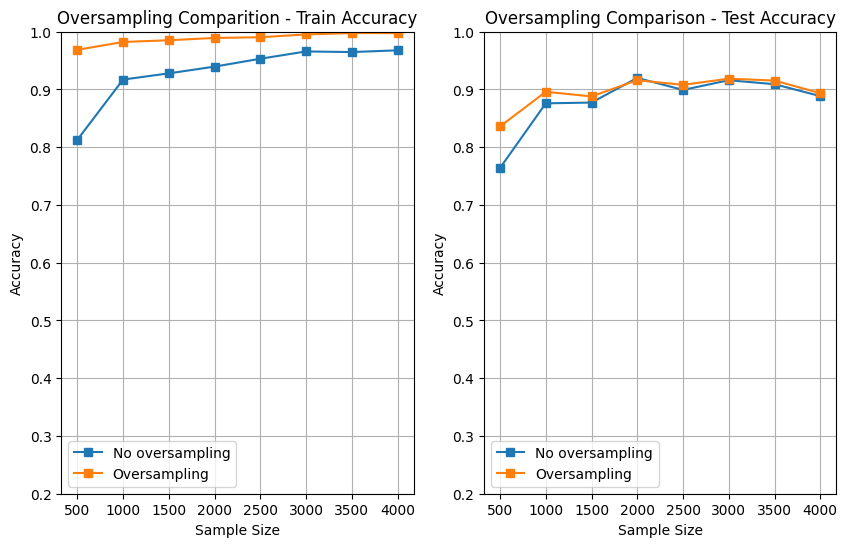

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(10, 6))

ax[0].plot(sample_sizes, train_accuracies[0,:], "s-", label="No oversampling")
ax[0].plot(sample_sizes, train_accuracies[1,:], "s-", label="Oversampling")
ax[0].set_title("Oversampling Comparition - Train Accuracy")
ax[0].set_xlabel("Sample Size")
ax[0].set_ylabel("Accuracy")
ax[0].set_ylim(0.2, 1.0)
ax[0].legend()
ax[0].grid()

ax[1].plot(sample_sizes, test_accuracies[0,:], "s-", label="No oversampling")
ax[1].plot(sample_sizes, test_accuracies[1,:], "s-", label="Oversampling")
ax[1].set_title("Oversampling Comparison - Test Accuracy")
ax[1].set_xlabel("Sample Size")
ax[1].set_ylabel("Accuracy")
ax[1].set_ylim(0.2, 1.0)
ax[1].legend()
ax[1].grid()

# we can see that the training performance may seem improved for any sample size, but in reality what 
# we have is overfitting, since the test accuracy doesnt improve. The take here, is that oversampling 
# may be helpful for small datasets 500-1000.

In [37]:
# Experiment with data augmentation
lr = 0.01
epochs = 50

sample_sizes = np.arange(500, 4001, 500)
data_augmentation = [False, True]

# IMPORTANT: the loss fun can be reused for multiple models, it doesnt store any state,
# but the optimizer needs to be redefined for each model since it stores the state of the parameters
loss_fn = nn.CrossEntropyLoss() # CrossEntropyLoss combines nn.LogSoftmax() and nn.NLLLoss()

train_accuracies = np.zeros((2, len(sample_sizes)))
test_accuracies = np.zeros((2, len(sample_sizes)))

for i, aug in enumerate(data_augmentation):
    for j, N in enumerate(sample_sizes):
        train_dl, test_dl = get_data(N, data_augmentation=aug)
        model = MNIST_FNN()
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)  
        train_acc, test_acc, losses = train_model(model, train_dl, test_dl, optimizer, loss_fn, epochs) 
        train_accuracies[i, j] = np.mean(train_acc[-5:])
        test_accuracies[i, j] = np.mean(test_acc[-5:])

C:\Users\Pablo\AppData\Local\Temp\ipykernel_22796\1048280502.py:26: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  X_train_noisy = X_train + np.random.random_sample(X_train.shape) / 2
C:\Users\Pablo\AppData\Local\Temp\ipykernel_22796\1048280502.py:26: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  X_train_noisy = X_train + np.random.random_sample(X_train.shape) / 2
C:\Users\Pablo\AppData\Local\Temp\ipykernel_22796\1048280502.py:26: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  X_train_noisy = X_train + np.random.random_sample(X_train.shape) / 2
C:\Users\Pablo\AppData\Local\Temp\ipykernel_22796\1048280502.py:26: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the fu

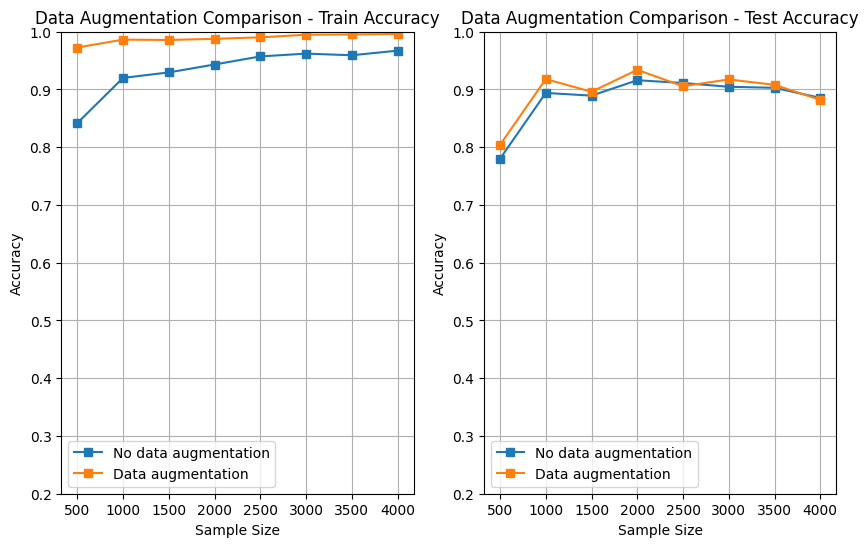

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(10, 6))

ax[0].plot(sample_sizes, train_accuracies[0,:], "s-", label="No data augmentation")
ax[0].plot(sample_sizes, train_accuracies[1,:], "s-", label="Data augmentation")
ax[0].set_title("Data Augmentation Comparison - Train Accuracy")
ax[0].set_xlabel("Sample Size")
ax[0].set_ylabel("Accuracy")
ax[0].set_ylim(0.2, 1.0)
ax[0].legend()
ax[0].grid()

ax[1].plot(sample_sizes, test_accuracies[0,:], "s-", label="No data augmentation")
ax[1].plot(sample_sizes, test_accuracies[1,:], "s-", label="Data augmentation")
ax[1].set_title("Data Augmentation Comparison - Test Accuracy")
ax[1].set_xlabel("Sample Size")
ax[1].set_ylabel("Accuracy")
ax[1].set_ylim(0.2, 1.0)
ax[1].legend()
ax[1].grid()

# we can see that data augmentation improves the performance of the model, both in train and test sets,
#  but the improvement is more significant in the test set, which means that data augmentation helps to 
# reduce overfitting. The take here, is that data augmentation helps with generalization, since the model
# is less able to memorize specif samples of the training set.